In [1]:
from dataset import sin_1d, DiffusionDataset, get_dataloader
from train import train_exact_gp, evaluate_metrics
from exactGPs import ExactGP
import torch
import matplotlib.pyplot as plt
import gpytorch
import numpy as np
from diffusion import Diffusion

In [4]:
## Set parameters
train_param = {
    'dataset_name': 'sin_1d',
    'x_normalise': True,
    'y_normalise': True,
    'seed': 42,
    'batch_size': 64,
    'train_ratio': 0.8,
    'test_ratio': 0.1,
    'shuffle': True,
    'T': 1000,
    'num_epochs': 100,
    'gp_lr': 0.01,
    'nn_lr': 0.0001,
    'optimiser': 'Adam',
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
}
plot_param = {
    'figsize': (7, 4),
    'grid_alpha': 0.5,
    'xlabel_fontsize': 12,
    'ylabel_fontsize': 12,
    'legend_fontsize': 11,
    'title_fontsize': 14,
    'xticks_fontsize': 11,
    'yticks_fontsize': 11,
    'scatter_size': 1,
}

# Get dataset -> dataset, train_loader, test_loader, val_loader, d, scalers

In [5]:
## Get training data
dataset = DiffusionDataset(dataset_name=train_param['dataset_name'], x_normalise=train_param['x_normalise'], y_normalise=train_param['y_normalise'])
x_scaler, y_scaler = dataset.get_scalers()
train_loader, val_loader, test_loader = get_dataloader(dataset, batch_size=train_param['batch_size'], train_ratio=train_param['train_ratio'], test_ratio=train_param['test_ratio'], shuffle=train_param['shuffle'], seed=train_param['seed'])
print(f"Number of training batches: {len(train_loader)}, samples: {len(train_loader)*train_param['batch_size']}")
print(f"Number of validation batches: {len(val_loader)}, samples: {len(val_loader)*train_param['batch_size']}")
print(f"Number of test batches: {len(test_loader)}, samples: {len(test_loader)*train_param['batch_size']}")

Reshaping x from 1D to 2D, shape: (4000,) -> (4000, 1)
Reshaping y from 1D to 2D, shape: (4000,) -> (4000, 1)
Number of training batches: 50, samples: 3200
Number of validation batches: 7, samples: 448
Number of test batches: 7, samples: 448


# Vanilla GPs

## Homoscedastic GP

In [6]:
## Flatten dataset to 1D for exact GP models
# Get datasets
print("Preparing flattened datasets for exact GP models training...")
train_dataset = dataset[train_loader.dataset.indices]
test_dataset = dataset[test_loader.dataset.indices]
val_dataset = dataset[val_loader.dataset.indices]

# Flatten datasets
gp_train_x, gp_train_y = train_dataset['x'].flatten(), train_dataset['y'].flatten() # y must be 1D for GP training
gp_test_x, gp_test_y = test_dataset['x'].flatten(), test_dataset['y'].flatten()
gp_val_x, gp_val_y = val_dataset['x'].flatten(), val_dataset['y'].flatten()
gp_true_y = y_scaler.transform(sin_1d(x_scaler.inverse_transform(gp_test_x.reshape(-1, 1)))[0]).flatten() # for rmse calculations
assert gp_train_x.dim() == 1 and gp_train_y.dim() == 1
assert gp_test_x.dim() == 1 and gp_test_y.dim() == 1
assert gp_val_x.dim() == 1 and gp_val_y.dim() == 1

print(f"Train x shape: {gp_train_x.shape}, test x shape: {gp_test_x.shape}, val x shape: {gp_val_x.shape}")

Preparing flattened datasets for exact GP models training...
Train x shape: torch.Size([3200]), test x shape: torch.Size([400]), val x shape: torch.Size([400])


In [7]:
## Train homoscedastic mean GP
mean_model, mean_likelihood, mean_rmses, mean_nlls = train_exact_gp(train_x=gp_train_x, train_y=gp_train_y, test_x=gp_test_x, 
                                                                    test_y=gp_test_y, mean_y=gp_true_y, lr=train_param['gp_lr'], num_trials=5,
                                                                    eval=True, training_iter=200, report_iter=100)


-------- Trial 1 of 5 --------
Intial parameters of GP model - lengthscale: 0.693   noise: 0.693   outputscale: 0.693
Iter 1/200 - Loss: 1.034   lengthscale: 0.698   noise: 0.688   outputscale: 0.688
Iter 101/200 - Loss: 0.974   lengthscale: 0.943   noise: 0.411   outputscale: 0.872
Trained parameters of GP model - lengthscale: 1.029   noise: 0.406   outputscale: 1.202
Evaluating GP model...
Best model updated: RMSE: 0.035   NLL: 1.055
-------- Trial 2 of 5 --------
Intial parameters of GP model - lengthscale: 0.693   noise: 0.693   outputscale: 0.693
Iter 1/200 - Loss: 1.034   lengthscale: 0.698   noise: 0.688   outputscale: 0.688
Iter 101/200 - Loss: 0.974   lengthscale: 0.943   noise: 0.411   outputscale: 0.872
Trained parameters of GP model - lengthscale: 1.029   noise: 0.406   outputscale: 1.201
Evaluating GP model...
-------- Trial 3 of 5 --------
Intial parameters of GP model - lengthscale: 0.693   noise: 0.693   outputscale: 0.693
Iter 1/200 - Loss: 1.034   lengthscale: 0.698  

In [8]:
## Save the models
torch.save({
    'model_state_dict': mean_model.state_dict(),
    'likelihood_state_dict': mean_likelihood.state_dict()
}, 'synthetic_models/mean_gp.pt')

In [ ]:
## Load model if already trained
mean_likelihood = gpytorch.likelihoods.GaussianLikelihood()
mean_model = ExactGP(train_x=gp_train_x, train_y=gp_train_y, likelihood=mean_likelihood)
checkpoint = torch.load('synthetic_models/mean_gp.pt')
mean_model.load_state_dict(checkpoint['model_state_dict'])
mean_likelihood.load_state_dict(checkpoint['likelihood_state_dict'])

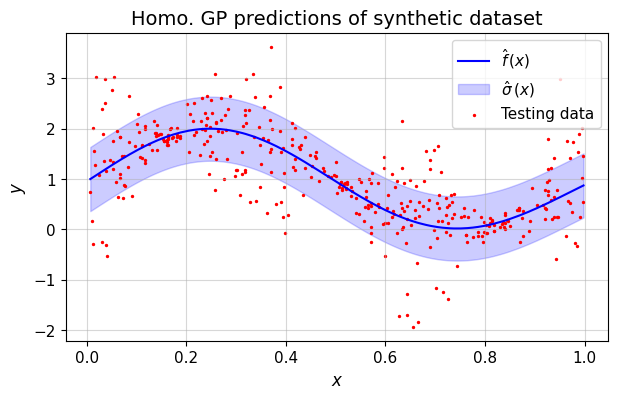

In [9]:
# Visualises predictions
mean_model.eval()
mean_likelihood.eval()
with torch.no_grad():
    mean_preds = mean_model(gp_test_x).mean.detach().numpy()
    epi_var = mean_model(gp_test_x).variance.detach().numpy()
    alo_var = mean_likelihood(mean_model(gp_test_x)).variance.detach().numpy() - epi_var
mean_plot = y_scaler.inverse_transform(mean_preds.reshape(-1, 1)).flatten()
x_plot = x_scaler.inverse_transform(gp_test_x.reshape(-1, 1)).flatten()
test_x_plot = x_scaler.inverse_transform(gp_test_x.reshape(-1, 1)).flatten()
test_y_plot = y_scaler.inverse_transform(gp_test_y.reshape(-1, 1)).flatten()

plt.figure(figsize=plot_param['figsize'])
plt.grid(alpha=plot_param['grid_alpha'])
plt.plot(x_plot[np.argsort(x_plot)], mean_plot[np.argsort(x_plot)], 'b-', label=r'$\hat{f}\,(x)$')
plt.fill_between(x_plot[np.argsort(x_plot)], mean_plot[np.argsort(x_plot)] - np.sqrt(alo_var[np.argsort(x_plot)]), mean_plot[np.argsort(x_plot)] + np.sqrt(alo_var[np.argsort(x_plot)]), color='b', alpha=0.2, label=r'$\hat{\sigma}\,(x)$')
plt.xticks(fontsize=plot_param['xticks_fontsize'])
plt.yticks(fontsize=plot_param['yticks_fontsize'])
plt.title('Homo. GP predictions of synthetic dataset', fontsize=plot_param['title_fontsize'])
plt.scatter(test_x_plot, test_y_plot, label='Testing data', color='r', s=2)
plt.xlabel(r'$x$', fontsize=plot_param['xlabel_fontsize'])
plt.ylabel(r'$y$', fontsize=plot_param['ylabel_fontsize'])
plt.legend(fontsize=plot_param['legend_fontsize'])

## Heteroscedastic GP

/opt/anaconda3/envs/dgp/lib/python3.11/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(


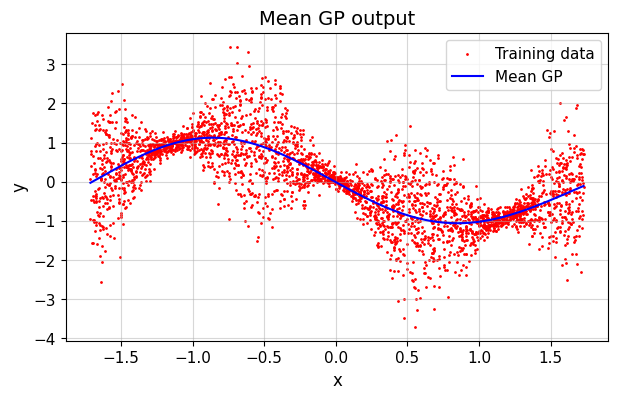

In [10]:
# Set the mean model to evaluation mode
mean_model.eval()
mean_likelihood.eval()
with torch.no_grad():
    mean_pred = mean_model(gp_train_x).mean

plt.figure(figsize=plot_param['figsize'])
plt.grid(alpha=plot_param['grid_alpha'])
plt.scatter(gp_train_x[np.argsort(gp_train_x)], gp_train_y[np.argsort(gp_train_x)], c='r', label='Training data', s=1)
plt.plot(gp_train_x[np.argsort(gp_train_x)], mean_pred[np.argsort(gp_train_x)], c='b', label='Mean GP')
plt.legend(fontsize=plot_param['legend_fontsize'])
plt.title('Mean GP output', fontsize=plot_param['title_fontsize'])
plt.xlabel('x', fontsize=plot_param['xlabel_fontsize'])
plt.ylabel('y', fontsize=plot_param['ylabel_fontsize'])
plt.xticks(fontsize=plot_param['xticks_fontsize'])
plt.yticks(fontsize=plot_param['yticks_fontsize'])
plt.show()

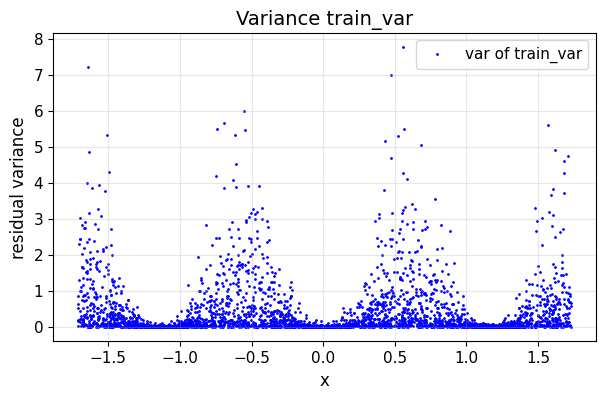

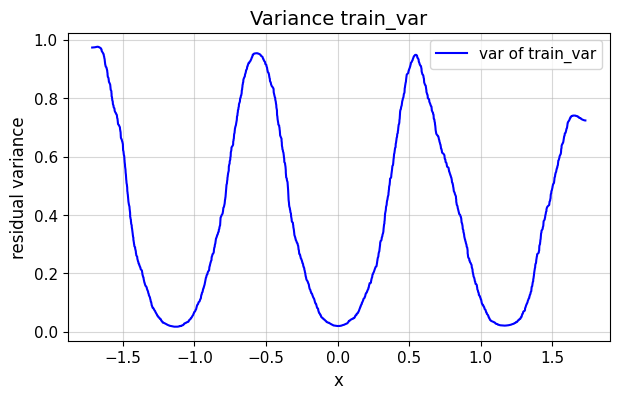

In [11]:
train_var = (gp_train_y - mean_pred)**2
plt.figure(figsize=plot_param['figsize'])
plt.grid(alpha=0.3)
plt.scatter(gp_train_x, train_var, c='b', label='var of train_var', s=1)
plt.title('Variance train_var', fontsize=plot_param['title_fontsize'])
plt.xlabel('x', fontsize=plot_param['xlabel_fontsize'])
plt.ylabel('residual variance', fontsize=plot_param['ylabel_fontsize'])
plt.xticks(fontsize=plot_param['xticks_fontsize'])
plt.yticks(fontsize=plot_param['yticks_fontsize'])
plt.legend(fontsize=plot_param['legend_fontsize'])
plt.show()

from scipy.ndimage import gaussian_filter
smoothed_train_var = torch.tensor(gaussian_filter(train_var[np.argsort(gp_train_x)], sigma=50))
sorted_train_x = gp_train_x[np.argsort(gp_train_x)]
plt.figure(figsize=plot_param['figsize'])
plt.grid(alpha=plot_param['grid_alpha'])
plt.plot(sorted_train_x, smoothed_train_var, c='b', label='var of train_var')
plt.title('Variance train_var', fontsize=plot_param['title_fontsize'])
plt.xlabel('x', fontsize=plot_param['xlabel_fontsize'])
plt.ylabel('residual variance', fontsize=plot_param['ylabel_fontsize'])
plt.xticks(fontsize=plot_param['xticks_fontsize'])
plt.yticks(fontsize=plot_param['yticks_fontsize'])
plt.legend(fontsize=plot_param['legend_fontsize'])
plt.show()

log_train_var = torch.log(smoothed_train_var) # for training

In [12]:
## Train the noise model for heteroscedastic prediction
noise_model, noise_likelihood = train_exact_gp(train_x=sorted_train_x, train_y=log_train_var, test_x=gp_test_x, 
                                                                    test_y=gp_test_y, mean_y=gp_true_y, lr=train_param['gp_lr'], num_trials=5,
                                                                    eval=False, training_iter=200, report_iter=100)

-------- Trial 1 of 1 --------
Intial parameters of GP model - lengthscale: 0.693   noise: 0.693   outputscale: 0.693
Iter 1/200 - Loss: 1.161   lengthscale: 0.688   noise: 0.688   outputscale: 0.698
Iter 101/200 - Loss: 0.499   lengthscale: 0.432   noise: 0.291   outputscale: 1.069
Trained parameters of GP model - lengthscale: 0.262   noise: 0.097   outputscale: 1.358


In [14]:
# Save the noise model and noise likelihood
torch.save({
    'model_state_dict': noise_model.state_dict(),
    'likelihood_state_dict': noise_likelihood.state_dict()
}, 'synthetic_models/noise_gp.pt')

In [26]:
# Load the noise model and noise likelihood if already trained
noise_likelihood = gpytorch.likelihoods.GaussianLikelihood()
noise_model = ExactGP(train_x=sorted_train_x, train_y=log_train_var, likelihood=noise_likelihood)
checkpoint = torch.load('synthetic_models/noise_gp.pt')
noise_model.load_state_dict(checkpoint['model_state_dict'])
noise_likelihood.load_state_dict(checkpoint['likelihood_state_dict'])

<All keys matched successfully>

In [19]:
## Evaluate heteroscedastic noise GP
print("Evaluating heteroscedastic GP...")
mean_model.eval()
mean_likelihood.eval()
noise_model.eval()
noise_likelihood.eval()

with torch.no_grad():
    mean_pred = mean_model(gp_test_x).mean
    noise_pred = torch.exp(noise_model(gp_test_x).mean)
    mean_epi_pred = mean_model(gp_test_x).variance.mean()
    noise_epi_pred = noise_model(gp_test_x).variance.mean()
    total_epi_pred = mean_epi_pred + noise_epi_pred

print(f"Total epipred variance: {total_epi_pred:.3f}, standard deviation: {np.sqrt(total_epi_pred):.3f}")
rmse = evaluate_metrics(pred_mean=mean_pred, pred_var=noise_pred, test_y=gp_test_y, mean_y=gp_true_y, type='rmse')
nll = evaluate_metrics(pred_mean=mean_pred, pred_var=noise_pred, test_y=gp_test_y, mean_y=gp_true_y, type='nll')

print(f"RMSE: {rmse}")
print(f"NLL: {nll}")

Evaluating heteroscedastic GP...
Total epipred variance: 0.001, standard deviation: 0.037
RMSE: 0.03504024894371985
NLL: 0.7155821919441223


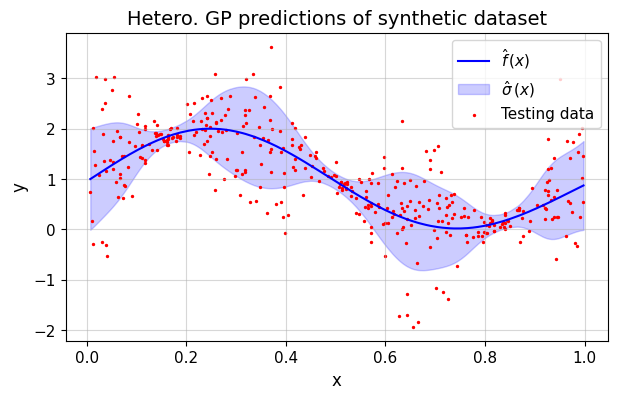

In [24]:
x_plot = gp_test_x[np.argsort(gp_test_x)]
x_plot = x_scaler.inverse_transform(x_plot.reshape(-1, 1)).flatten()
mean_plot = mean_pred[np.argsort(gp_test_x)]
mean_plot = y_scaler.inverse_transform(mean_plot.reshape(-1, 1)).flatten()
noise_plot = noise_pred[np.argsort(gp_test_x)].detach().numpy()

plt.figure(figsize=plot_param['figsize'])
plt.grid(alpha=plot_param['grid_alpha'])
plt.plot(x_plot, mean_plot, 'b-', label=r'$\hat{f}\,(x)$')
plt.fill_between(x_plot, mean_plot - noise_plot**0.5, mean_plot + noise_plot**0.5, color='b', alpha=0.2, label=r'$\hat{\sigma}\,(x)$')
plt.scatter(test_x_plot, test_y_plot, c='r', label='Testing data', s=2)
plt.title('Hetero. GP predictions of synthetic dataset', fontsize=plot_param['title_fontsize'])
plt.xlabel('x', fontsize=plot_param['xlabel_fontsize'])
plt.ylabel('y', fontsize=plot_param['ylabel_fontsize'])
plt.xticks(fontsize=plot_param['xticks_fontsize'])
plt.yticks(fontsize=plot_param['yticks_fontsize'])
plt.legend(fontsize=plot_param['legend_fontsize'])
# plt.ylim(-2.5, 4)
plt.show()

# SVGPs